# 📊 EDA - Phân Tích Khám Phá Dữ Liệu Udemy
**Đồ án: Phân Tích và Trực Quan Hóa Dữ Liệu Khóa Học Trực Tuyến Trên Nền Tảng Udemy**

> Dữ liệu 2011–2026 

## 0. Import thư viện & Load dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ Import thư viện thành công')

✅ Import thư viện thành công


In [ ]:

FILE = 'udemy_2011_2013.csv'

df = pd.read_csv(FILE)
print(f'✅ Load dataset: {len(df):,} rows')

df.head(10)


✅ Load dataset: 9,172 rows


,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,estimated_revenue,data_source
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments,3535353535353535353535353535353535353535353535...,original_2011_2017
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments,7575757575757575757575757575757575757575757575...,original_2011_2017
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments,7575757575757575757575757575757575757575757575...,original_2011_2017
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments,7575757575757575757575757575757575757575757575...,original_2011_2017
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments,7575757575757575757575757575757575757575757575...,original_2011_2017
5,1122832,#6 Piano Hand Coordination: Play Open 10 Balla...,True,65,2015,3,21,Intermediate Level,44 mins,2017-03-08T17:53:36Z,Musical Instruments,6565656565656565656565656565656565656565656565...,original_2011_2017
6,1123184,#7 Piano Hand Coordination: Play Piano Runs in...,True,65,2015,2,25,Intermediate Level,1 hour,2017-03-08T18:09:32Z,Musical Instruments,6565656565656565656565656565656565656565656565...,original_2011_2017
7,768028,* An Integrated Approach to the Fundamentals o...,True,200,134,14,123,All Levels,5.5 hours,2016-03-15T17:23:07Z,Business Finance,2002002002002002002002002002002002002002002002...,original_2011_2017
8,206592,:::Beginners Guide To Creating Amazing Images ...,True,25,72,5,17,Beginner Level,1 hour,2014-04-29T19:50:31Z,Graphic Design,2525252525252525252525252525252525252525252525...,original_2011_2017
9,738910,[Value Investing] Where White People Keep Thei...,True,200,2715,70,20,Expert Level,4 hours,2016-05-25T21:04:41Z,Business Finance,2002002002002002002002002002002002002002002002...,original_2011_2017


---
## 1. Tổng quan Dataset

In [7]:
print('=' * 50)
print('THÔNG TIN TỔNG QUAN DATASET')
print('=' * 50)
print(f'Số dòng (khóa học):  {len(df):,}')
print(f'Số cột (thuộc tính): {df.shape[1]}')
print(f'Bộ nhớ sử dụng:      {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
print('Kiểu dữ liệu từng cột:')
print(df.dtypes)

THÔNG TIN TỔNG QUAN DATASET
Số dòng (khóa học):  9,172
Số cột (thuộc tính): 13
Bộ nhớ sử dụng:      35.02 MB

Kiểu dữ liệu từng cột:
course_id              int64
course_title             str
is_paid                 bool
price                    str
num_subscribers        int64
num_reviews            int64
num_lectures           int64
level                    str
content_duration         str
published_timestamp      str
subject                  str
estimated_revenue        str
data_source              str
dtype: object


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   course_id            9172 non-null   int64
 1   course_title         9172 non-null   str  
 2   is_paid              9172 non-null   bool 
 3   price                9172 non-null   str  
 4   num_subscribers      9172 non-null   int64
 5   num_reviews          9172 non-null   int64
 6   num_lectures         9172 non-null   int64
 7   level                9172 non-null   str  
 8   content_duration     9172 non-null   str  
 9   published_timestamp  9172 non-null   str  
 10  subject              9172 non-null   str  
 11  estimated_revenue    9172 non-null   str  
 12  data_source          9172 non-null   str  
dtypes: bool(1), int64(4), str(8)
memory usage: 35.0 MB


In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
course_id,9172.0,NaN,NaN,NaN,275655.590929,393994.02201,4000.0,6292.75,8583.5,563977.0,1282064.0
course_title,9172,4050,Typography Design Masterclass,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_paid,9172,2,True,8401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,9172,55,149.99,863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_subscribers,9172.0,NaN,NaN,NaN,5506.164959,10529.568802,0.0,999.75,2570.0,6112.5,268923.0
num_reviews,9172.0,NaN,NaN,NaN,458.113716,1035.244298,0.0,31.0,176.0,481.0,27445.0
num_lectures,9172.0,NaN,NaN,NaN,53.989969,47.163911,0.0,24.0,42.0,70.0,779.0
level,9172,4,All Levels,4670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content_duration,9172,471,1 hour,607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_timestamp,9172,6209,2021-07-11T00:00:00Z,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Kiểm tra chất lượng dữ liệu

In [10]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print('✅ Không có giá trị thiếu (missing values)')
else:
    print('⚠️  Các cột có giá trị thiếu:')
    display(missing_df)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Missing Values (%)', fontweight='bold')
    ax.set_xlabel('Phần trăm thiếu')
    plt.tight_layout()
    plt.show()

✅ Không có giá trị thiếu (missing values)


In [11]:
# Duplicate rows
dup_count = df.duplicated().sum()
print(f'Số dòng trùng lặp: {dup_count}')

# Duplicate course titles
if 'course_title' in df.columns:
    dup_titles = df['course_title'].duplicated().sum()
    print(f'Tiêu đề khóa học trùng: {dup_titles}')
    if dup_titles > 0:
        print('\nTop 10 tiêu đề trùng nhiều nhất:')
        display(df['course_title'].value_counts().head(10))

Số dòng trùng lặp: 6
Tiêu đề khóa học trùng: 5122

Top 10 tiêu đề trùng nhiều nhất:


course_title
Typography Design Masterclass                  42
Professional Motion Graphics Design Course     41
Professional 3D Design Design Course           38
Professional Logo Design Course                38
Digital Illustration Design Masterclass        37
Learn Adobe XD from Scratch                    35
The Complete Photoshop Course for Beginners    34
Brand Identity Design Masterclass              33
UI/UX Design Masterclass                       33
Motion Graphics Design Masterclass             33
Name: count, dtype: int64

---
## 3. Tiền xử lý dữ liệu

In [ ]:

# Xử lý giá tiền
if 'price' in df.columns:
    df['price'] = df['price'].replace('Free', 0)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Xử lý thời lượng khóa học
def parse_duration(x):
    if pd.isna(x): return np.nan
    x = str(x).lower().strip()
    try:
        if 'hour' in x: return float(x.replace('hours', '').replace('hour', '').strip())
        elif 'min' in x: return float(x.replace('mins', '').replace('min', '').strip()) / 60.0
        return float(x)
    except:
        return np.nan

if 'content_duration' in df.columns:
    df['content_duration'] = df['content_duration'].apply(parse_duration)

# Ép kiểu an toàn cho các cột số khác
for col in ['num_subscribers', 'num_reviews', 'num_lectures']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('✅ Đã làm sạch các cột số bị lỗi chữ')

# ==========================================
# 2. TIỀN XỬ LÝ & TẠO FEATURE MỚI
# ==========================================
# Parse datetime
if 'published_timestamp' in df.columns:
    df['published_timestamp'] = pd.to_datetime(df['published_timestamp'], errors='coerce')
    df['year']  = df['published_timestamp'].dt.year
    df['month'] = df['published_timestamp'].dt.month
    df['quarter'] = df['published_timestamp'].dt.quarter
    print('✅ Đã parse published_timestamp')

# is_paid → nhãn
if 'is_paid' in df.columns:
    df['paid_label'] = df['is_paid'].map({
        True: 'Paid', False: 'Free', 
        1: 'Paid', 0: 'Free',
        'True': 'Paid', 'False': 'Free',
        'TRUE': 'Paid', 'FALSE': 'Free'
    })
    print('✅ Đã tạo paid_label')
# Bắt buộc tính lại Estimated revenue (do dữ liệu trong file csv bị lỗi nhân chuỗi)
df['estimated_revenue'] = df['price'] * df['num_subscribers']

# Review-to-subscriber ratio
if 'num_reviews' in df.columns and 'num_subscribers' in df.columns:
    df['review_ratio'] = (df['num_reviews'] / df['num_subscribers'].replace(0, np.nan)).round(4)

# ==========================================
# 3. TẠO PHÂN NHÓM (BINS)
# ==========================================
# Price range bins
price_bins   = [0, 0.01, 25, 50, 75, 100, 125, 150, 175, 200, 999]
price_labels = ['Free','1-25','26-50','51-75','76-100','101-125','126-150','151-175','176-200','200+']
df['price_range'] = pd.cut(df['price'], bins=price_bins, labels=price_labels, right=True, include_lowest=True)
print('✅ Đã tạo price_range')

# Content duration bins
dur_bins   = [0, 2, 5, 10, 20, 40, 60, 999]
dur_labels = ['0-2h','2-5h','5-10h','10-20h','20-40h','40-60h','60h+']
df['duration_range'] = pd.cut(df['content_duration'], bins=dur_bins, labels=dur_labels, right=True, include_lowest=True)
print('✅ Đã tạo duration_range')

print(f'\nDataset sau xử lý: {df.shape}')


✅ Đã làm sạch các cột số bị lỗi chữ
✅ Đã parse published_timestamp
✅ Đã tạo paid_label
✅ Đã tạo price_range
✅ Đã tạo duration_range

Dataset sau xử lý: (9172, 20)


---
## 4. Phân tích đơn biến (Univariate Analysis)

### 4.1 Biến phân loại (Categorical)

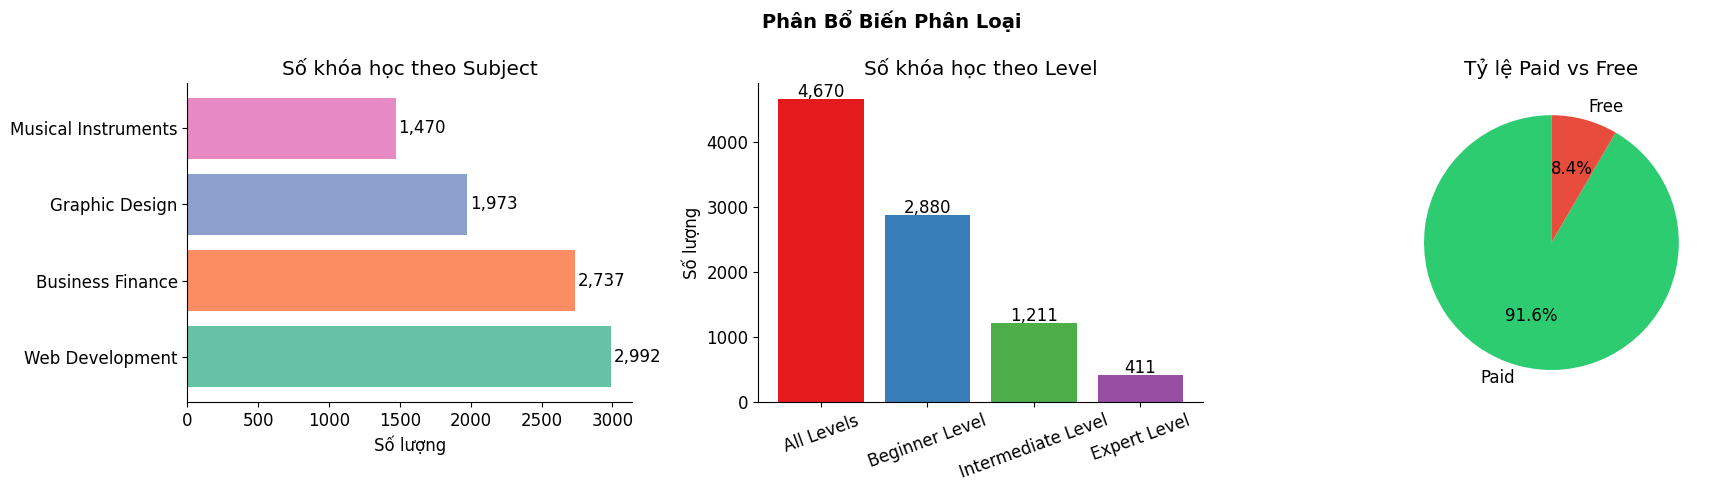

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân Bổ Biến Phân Loại', fontsize=14, fontweight='bold')

# Subject
subject_counts = df['subject'].value_counts()
axes[0].barh(subject_counts.index, subject_counts.values,
             color=sns.color_palette('Set2', len(subject_counts)))
axes[0].set_title('Số khóa học theo Subject')
axes[0].set_xlabel('Số lượng')
for i, v in enumerate(subject_counts.values):
    axes[0].text(v + 20, i, f'{v:,}', va='center')

# Level
level_counts = df['level'].value_counts()
axes[1].bar(level_counts.index, level_counts.values,
            color=sns.color_palette('Set1', len(level_counts)))
axes[1].set_title('Số khóa học theo Level')
axes[1].set_ylabel('Số lượng')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(level_counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center')

# Paid vs Free
paid_counts = df['paid_label'].value_counts()
axes[2].pie(paid_counts.values, labels=paid_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#2ecc71', '#e74c3c'])
axes[2].set_title('Tỷ lệ Paid vs Free')

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Biến số (Numerical) - Phân phối

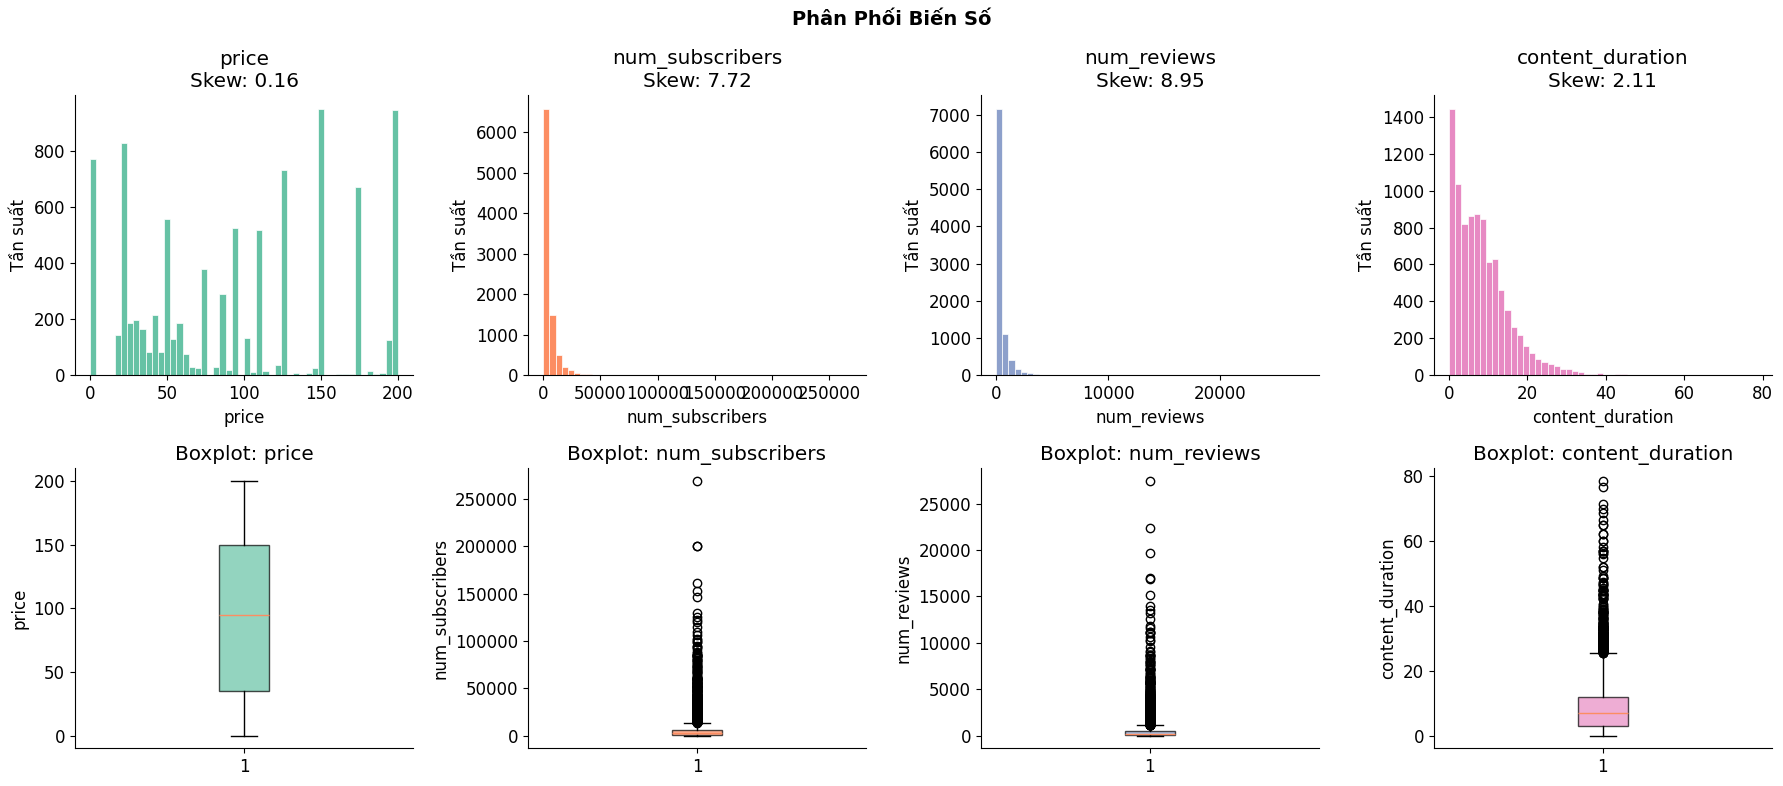

In [26]:
num_features = ['price', 'num_subscribers', 'num_reviews', 'content_duration']
num_features = [c for c in num_features if c in df.columns]

fig, axes = plt.subplots(2, len(num_features), figsize=(18, 8))
fig.suptitle('Phân Phối Biến Số', fontsize=14, fontweight='bold')

for i, col in enumerate(num_features):
    data = df[col].dropna()
    
    # Histogram
    axes[0, i].hist(data, bins=50, color=sns.color_palette('Set2')[i],
                    edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(f'{col}\nSkew: {data.skew():.2f}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Tần suất')
    
    # Boxplot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=sns.color_palette('Set2')[i], alpha=0.7))
    axes[1, i].set_title(f'Boxplot: {col}')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Thống kê mô tả chi tiết
stats_df = df[num_features].agg(['mean','median','std','min','max',
                                   lambda x: x.quantile(0.25),
                                   lambda x: x.quantile(0.75),
                                   'skew']).T
stats_df.columns = ['Mean','Median','Std','Min','Max','Q1','Q3','Skewness']
stats_df.round(2)

,Mean,Median,Std,Min,Max,Q1,Q3,Skewness
price,95.17,94.99,64.33,0.0,200.0,35.00,149.99,0.16
num_subscribers,5506.16,2570.00,10529.57,0.0,268923.0,999.75,6112.50,7.72
num_reviews,458.11,176.00,1035.24,0.0,27445.0,31.00,481.00,8.95
content_duration,8.58,7.00,7.47,0.0,78.5,3.00,12.00,2.11


### 4.3 Phân tích giá (Price)

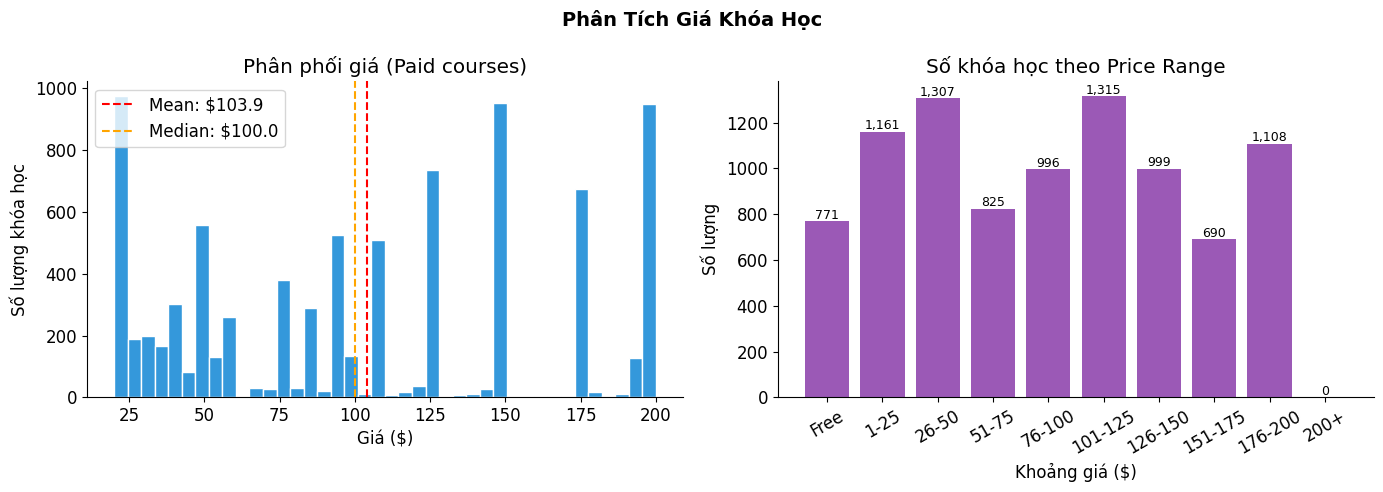

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân Tích Giá Khóa Học', fontsize=14, fontweight='bold')

# Phân phối giá (chỉ paid)
paid_prices = df[df['price'] > 0]['price']
axes[0].hist(paid_prices, bins=40, color='#3498db', edgecolor='white')
axes[0].axvline(paid_prices.mean(), color='red', linestyle='--',
                label=f'Mean: ${paid_prices.mean():.1f}')
axes[0].axvline(paid_prices.median(), color='orange', linestyle='--',
                label=f'Median: ${paid_prices.median():.1f}')
axes[0].set_title('Phân phối giá (Paid courses)')
axes[0].set_xlabel('Giá ($)')
axes[0].set_ylabel('Số lượng khóa học')
axes[0].legend()

# Price range
price_range_counts = df['price_range'].value_counts().sort_index()
bars = axes[1].bar(price_range_counts.index.astype(str),
                   price_range_counts.values, color='#9b59b6')
axes[1].set_title('Số khóa học theo Price Range')
axes[1].set_xlabel('Khoảng giá ($)')
axes[1].set_ylabel('Số lượng')
axes[1].tick_params(axis='x', rotation=30)
for bar, v in zip(bars, price_range_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_price.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Phân tích theo thời gian (Time Series)

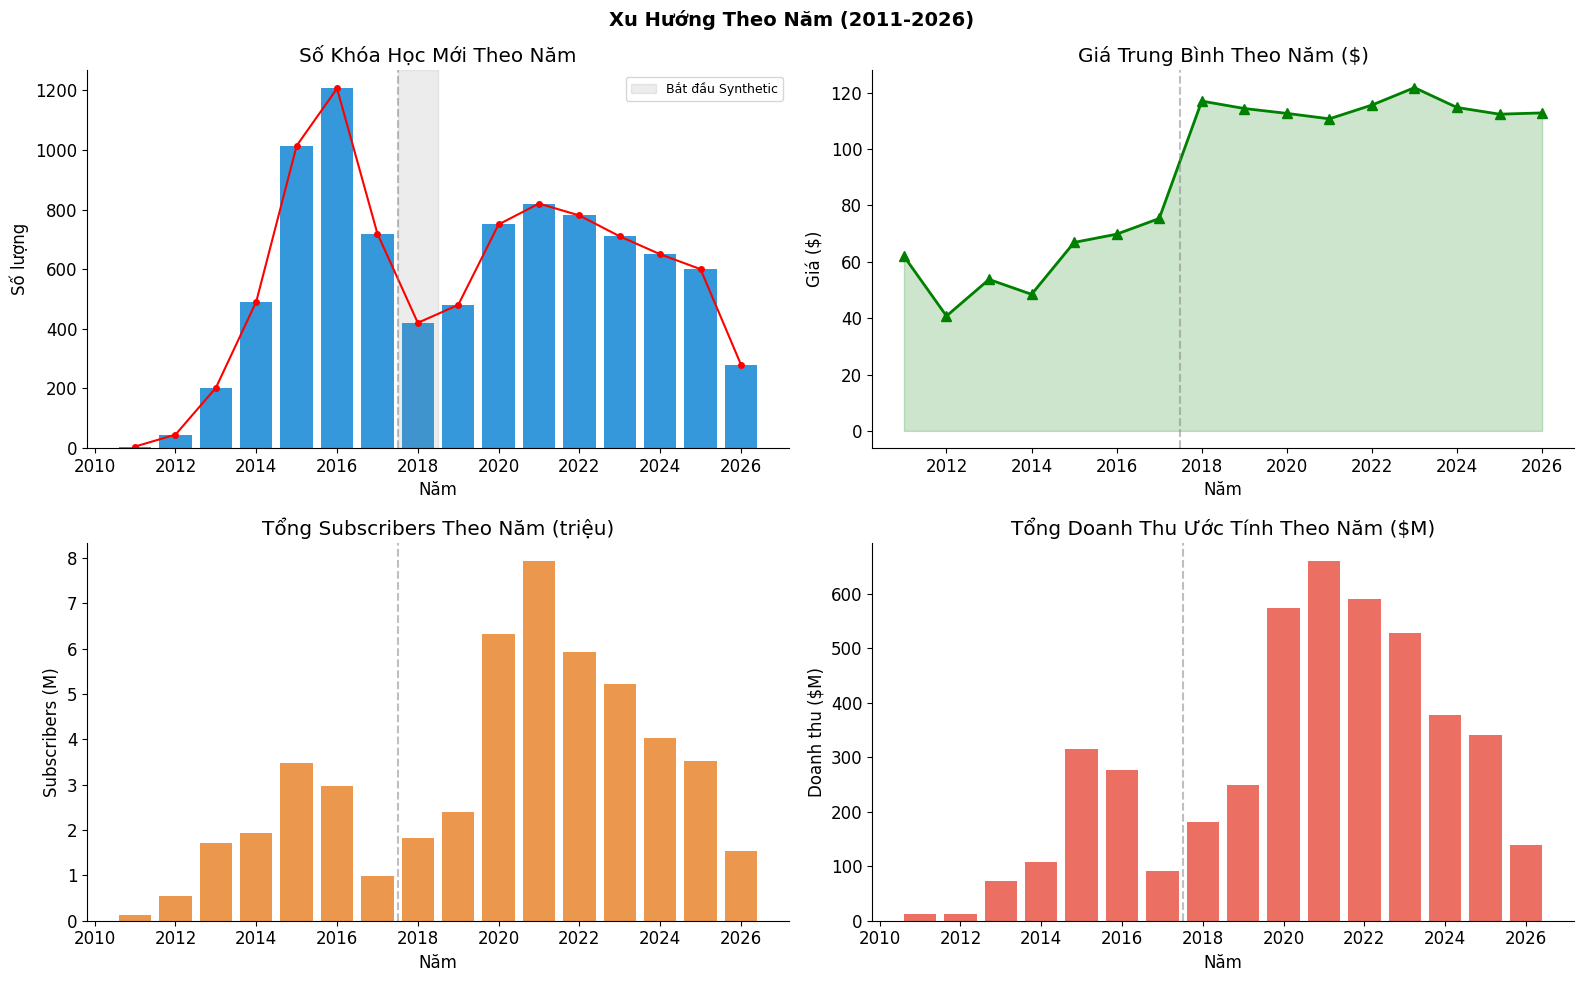

,year,n_courses,avg_price,total_subscribers,total_revenue
0,2011,5,62.000000,119028,1.164342e+07
1,2012,45,40.777778,555339,1.177347e+07
2,2013,202,53.762376,1723438,7.265220e+07
3,2014,491,48.472505,1930406,1.069390e+08
4,2015,1014,66.893491,3475324,3.145104e+08
5,2016,1206,69.825871,2966644,2.766332e+08
6,2017,719,75.389430,990977,9.083068e+07
7,2018,420,117.062190,1827925,1.815909e+08
8,2019,480,114.428292,2405907,2.494533e+08
9,2020,750,112.697493,6329361,5.733122e+08


In [29]:
# Ép kiểu dứt điểm thành dạng số trước khi groupby
for col in ['price', 'num_subscribers', 'estimated_revenue']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

yearly = df.groupby('year').agg(
    n_courses        = ('course_title' if 'course_title' in df.columns else 'price', 'count'),
    avg_price        = ('price', 'mean'),
    total_subscribers= ('num_subscribers', 'sum'),
    total_revenue    = ('estimated_revenue', 'sum')
).reset_index()

# ... (Giữ nguyên toàn bộ phần vẽ biểu đồ bên dưới) ...

yearly = df.groupby('year').agg(
    n_courses        = ('course_title' if 'course_title' in df.columns else 'price', 'count'),
    avg_price        = ('price', 'mean'),
    total_subscribers= ('num_subscribers', 'sum'),
    total_revenue    = ('estimated_revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Xu Hướng Theo Năm (2011-2026)', fontsize=14, fontweight='bold')

# Số khóa học
axes[0,0].bar(yearly['year'], yearly['n_courses'], color='#3498db')
axes[0,0].plot(yearly['year'], yearly['n_courses'], 'ro-', markersize=4)
axes[0,0].set_title('Số Khóa Học Mới Theo Năm')
axes[0,0].set_ylabel('Số lượng')
axes[0,0].axvspan(2017.5, 2018.5, alpha=0.15, color='gray', label='Bắt đầu Synthetic')
axes[0,0].legend(fontsize=9)

# Giá trung bình
axes[0,1].plot(yearly['year'], yearly['avg_price'], 'g^-', markersize=7, linewidth=2)
axes[0,1].fill_between(yearly['year'], yearly['avg_price'], alpha=0.2, color='green')
axes[0,1].set_title('Giá Trung Bình Theo Năm ($)')
axes[0,1].set_ylabel('Giá ($)')

# Tổng subscribers
axes[1,0].bar(yearly['year'], yearly['total_subscribers']/1e6,
              color='#e67e22', alpha=0.8)
axes[1,0].set_title('Tổng Subscribers Theo Năm (triệu)')
axes[1,0].set_ylabel('Subscribers (M)')

# Tổng revenue
axes[1,1].bar(yearly['year'], yearly['total_revenue']/1e6,
              color='#e74c3c', alpha=0.8)
axes[1,1].set_title('Tổng Doanh Thu Ước Tính Theo Năm ($M)')
axes[1,1].set_ylabel('Doanh thu ($M)')

for ax in axes.flatten():
    ax.set_xlabel('Năm')
    ax.axvline(x=2017.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
display(yearly)

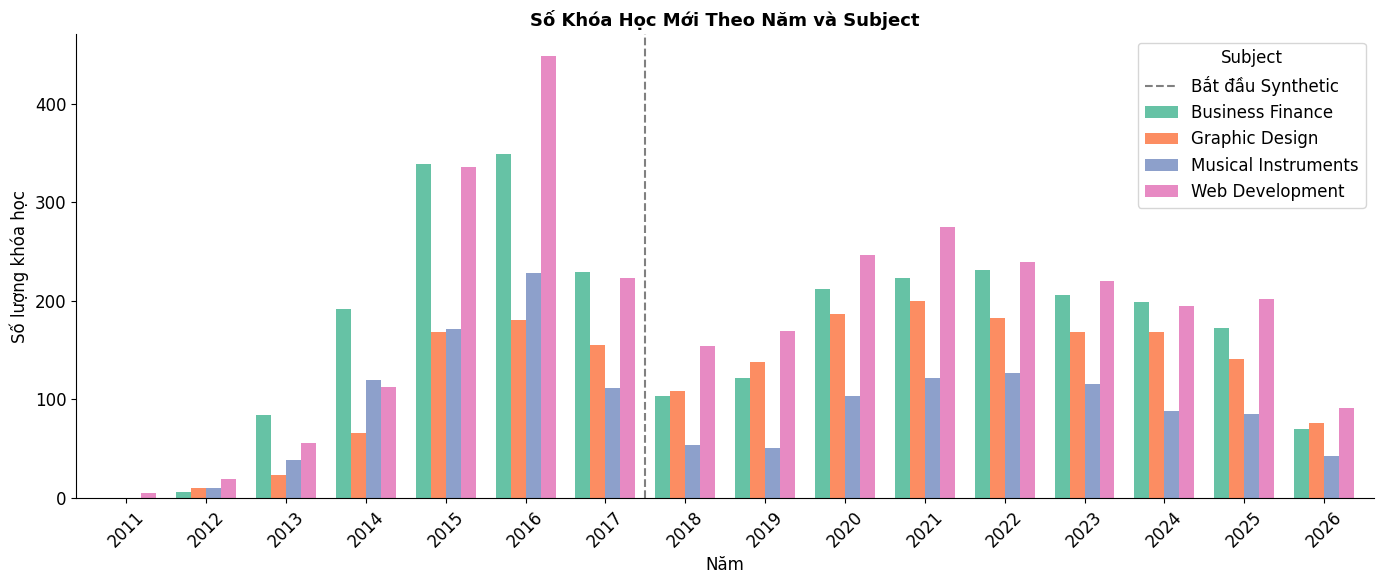

In [30]:
# Số khóa học theo năm & subject
yearly_subject = df.groupby(['year','subject']).size().reset_index(name='count')
pivot = yearly_subject.pivot(index='year', columns='subject', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Số Khóa Học Mới Theo Năm và Subject', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Số lượng khóa học')
ax.axvline(x=pivot.index.tolist().index(2018)-0.5 if 2018 in pivot.index else 6.5,
           color='gray', linestyle='--', label='Bắt đầu Synthetic')
ax.legend(title='Subject')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_yearly_subject.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Phân tích theo Subject & Level

In [31]:
subject_stats = df.groupby('subject').agg(
    n_courses        = ('price', 'count'),
    avg_price        = ('price', 'mean'),
    total_subscribers= ('num_subscribers', 'sum'),
    avg_subscribers  = ('num_subscribers', 'mean'),
    total_reviews    = ('num_reviews', 'sum'),
    total_revenue    = ('estimated_revenue', 'sum'),
    avg_duration     = ('content_duration', 'mean')
).round(2).reset_index()

subject_stats['total_revenue_M'] = (subject_stats['total_revenue']/1e6).round(1)
subject_stats['total_subscribers_M'] = (subject_stats['total_subscribers']/1e6).round(2)

display(subject_stats[['subject','n_courses','avg_price','total_subscribers_M',
                         'avg_subscribers','total_revenue_M','avg_duration']])

,subject,n_courses,avg_price,total_subscribers_M,avg_subscribers,total_revenue_M,avg_duration
0,Business Finance,2737,103.30,9.66,3528.05,962.6,8.04
1,Graphic Design,1973,91.92,7.20,3647.48,620.4,9.38
2,Musical Instruments,1470,75.11,3.76,2561.19,298.1,7.31
3,Web Development,2992,99.72,29.88,9988.26,2640.5,9.16


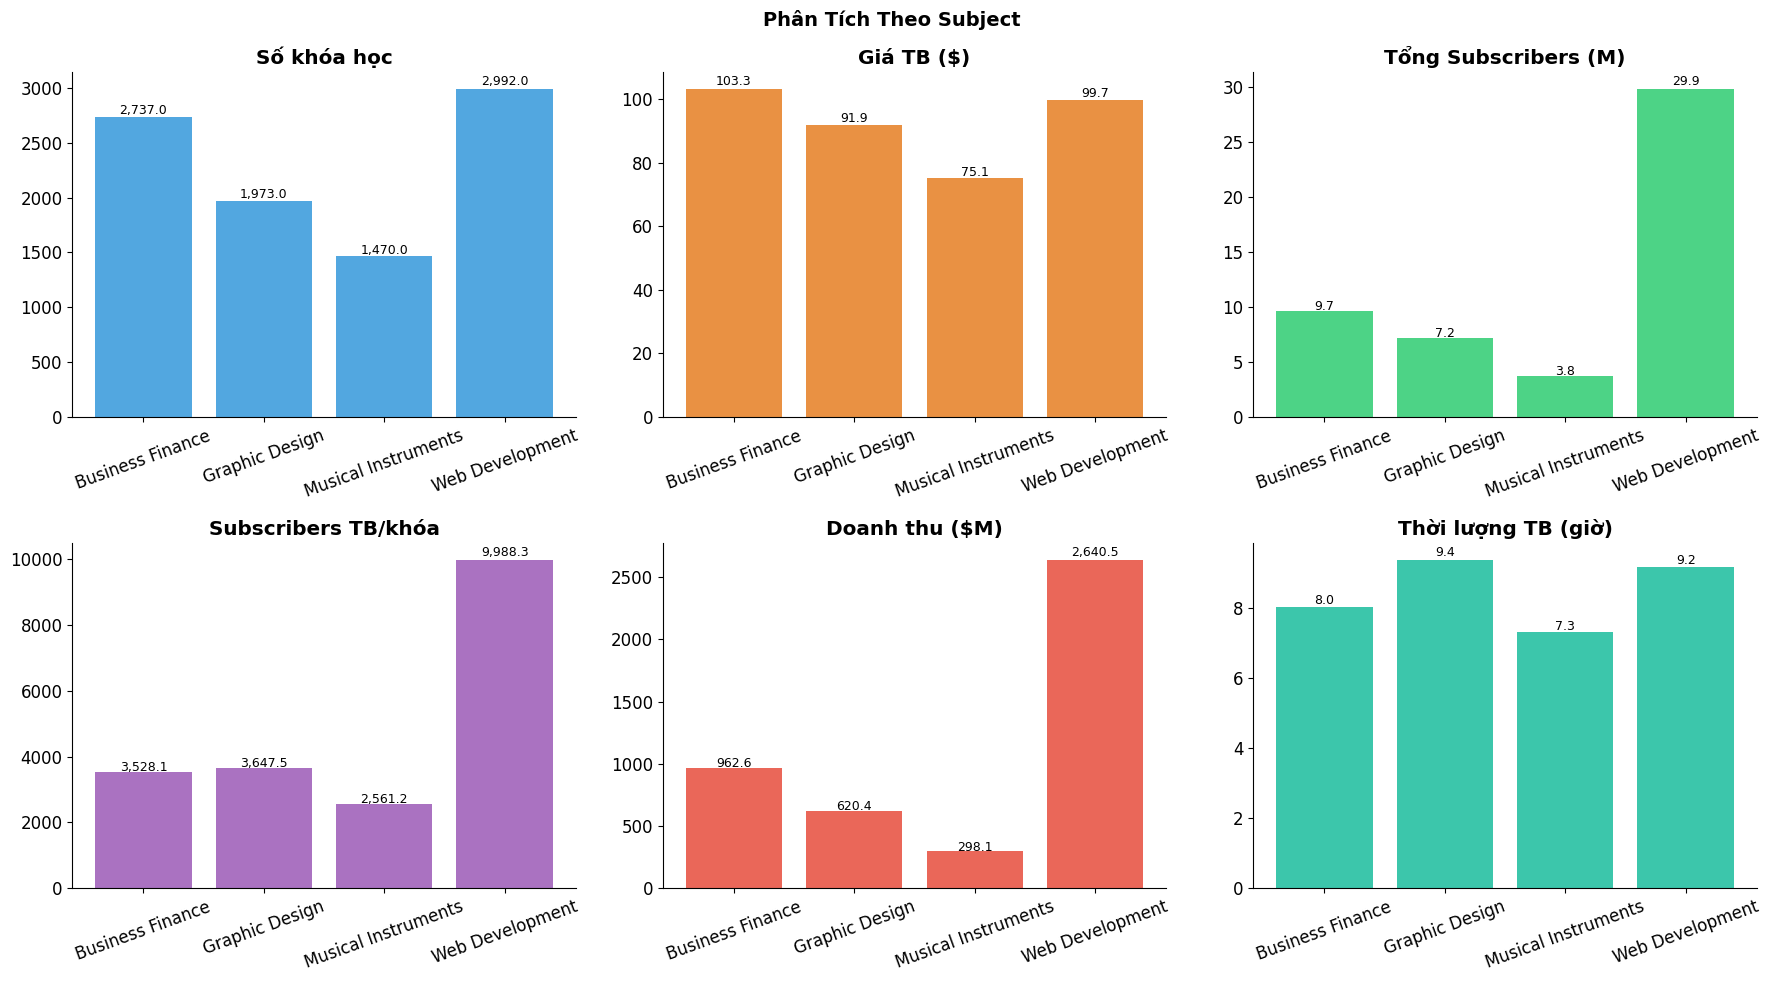

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phân Tích Theo Subject', fontsize=14, fontweight='bold')

metrics = [
    ('n_courses',           'Số khóa học',            '#3498db'),
    ('avg_price',           'Giá TB ($)',              '#e67e22'),
    ('total_subscribers_M', 'Tổng Subscribers (M)',    '#2ecc71'),
    ('avg_subscribers',     'Subscribers TB/khóa',     '#9b59b6'),
    ('total_revenue_M',     'Doanh thu ($M)',           '#e74c3c'),
    ('avg_duration',        'Thời lượng TB (giờ)',     '#1abc9c'),
]

for ax, (col, title, color) in zip(axes.flatten(), metrics):
    bars = ax.bar(subject_stats['subject'], subject_stats[col],
                  color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, subject_stats[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:,.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

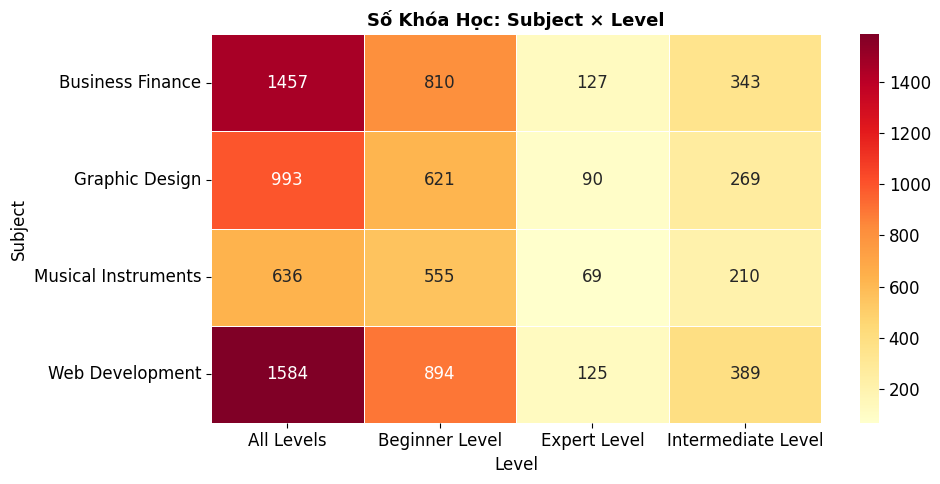

In [33]:
# Heatmap: Subject × Level
heat = df.groupby(['subject','level']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Số Khóa Học: Subject × Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Level')
ax.set_ylabel('Subject')
plt.tight_layout()
plt.savefig('eda_heatmap_subject_level.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Phân tích tương quan (Correlation)

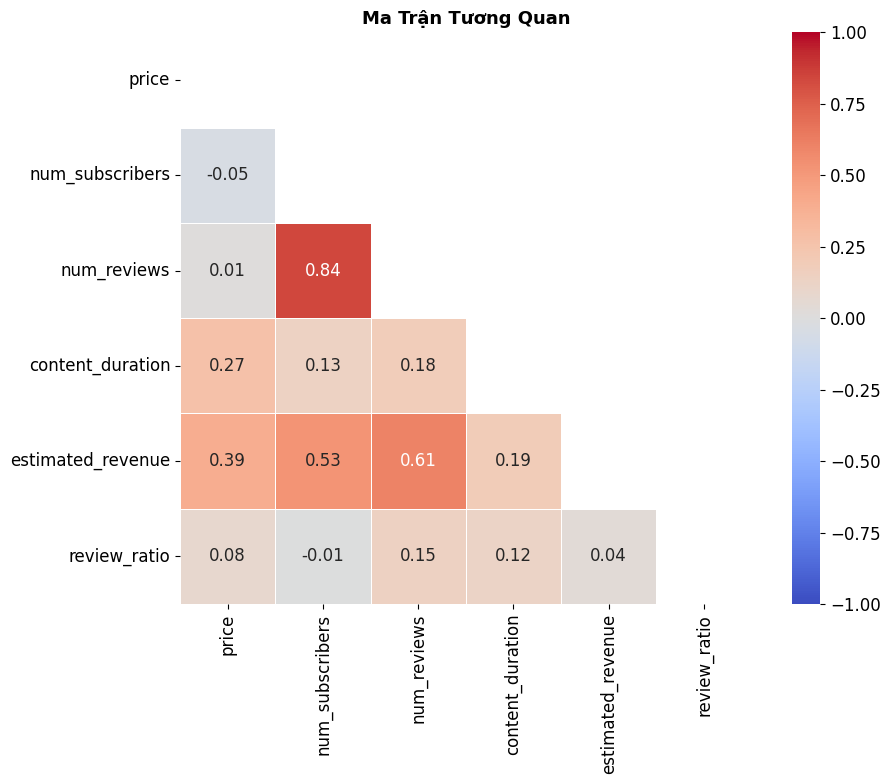


Tương quan với num_subscribers (sắp xếp):
num_reviews          0.837696
estimated_revenue    0.528449
content_duration     0.133012
review_ratio        -0.006686
price               -0.045797
Name: num_subscribers, dtype: float64


In [34]:
corr_cols = ['price','num_subscribers','num_reviews','content_duration',
              'estimated_revenue','review_ratio']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Ma Trận Tương Quan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTương quan với num_subscribers (sắp xếp):')
print(corr_matrix['num_subscribers'].drop('num_subscribers').sort_values(ascending=False))

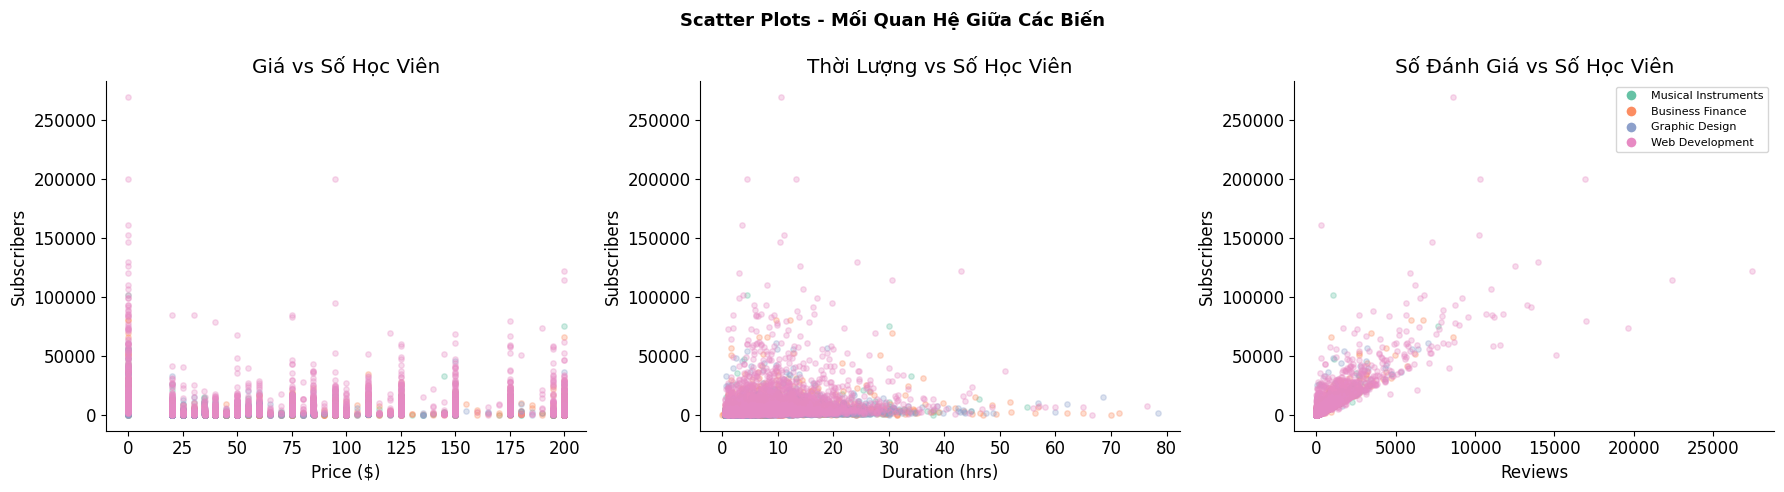

In [35]:
# Scatter plots - mối quan hệ key
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatter Plots - Mối Quan Hệ Giữa Các Biến', fontsize=13, fontweight='bold')

subjects = df['subject'].unique()
colors = dict(zip(subjects, sns.color_palette('Set2', len(subjects))))

for subj in subjects:
    mask = df['subject'] == subj
    
    # Price vs Subscribers
    axes[0].scatter(df.loc[mask,'price'],
                    df.loc[mask,'num_subscribers'],
                    alpha=0.3, s=15, color=colors[subj], label=subj)
    
    # Duration vs Subscribers
    axes[1].scatter(df.loc[mask,'content_duration'],
                    df.loc[mask,'num_subscribers'],
                    alpha=0.3, s=15, color=colors[subj], label=subj)
    
    # Reviews vs Subscribers
    axes[2].scatter(df.loc[mask,'num_reviews'],
                    df.loc[mask,'num_subscribers'],
                    alpha=0.3, s=15, color=colors[subj], label=subj)

axes[0].set_title('Giá vs Số Học Viên'); axes[0].set_xlabel('Price ($)'); axes[0].set_ylabel('Subscribers')
axes[1].set_title('Thời Lượng vs Số Học Viên'); axes[1].set_xlabel('Duration (hrs)'); axes[1].set_ylabel('Subscribers')
axes[2].set_title('Số Đánh Giá vs Số Học Viên'); axes[2].set_xlabel('Reviews'); axes[2].set_ylabel('Subscribers')

handles = [plt.Line2D([0],[0], marker='o', color='w',
            markerfacecolor=colors[s], markersize=8, label=s) for s in subjects]
axes[2].legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Phân tích Outliers

In [36]:
def detect_outliers_iqr(series, name):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name:<25} | Q1={Q1:>10.1f} | Q3={Q3:>10.1f} | '
          f'Lower={lower:>10.1f} | Upper={upper:>10.1f} | '
          f'Outliers={len(outliers):>6} ({len(outliers)/len(series)*100:.1f}%)')
    return lower, upper

print('PHÁT HIỆN OUTLIERS (phương pháp IQR)')
print('-' * 95)
for col in ['price','num_subscribers','num_reviews','content_duration']:
    if col in df.columns:
        detect_outliers_iqr(df[col].dropna(), col)

PHÁT HIỆN OUTLIERS (phương pháp IQR)
-----------------------------------------------------------------------------------------------
price                     | Q1=      35.0 | Q3=     150.0 | Lower=    -137.5 | Upper=     322.5 | Outliers=     0 (0.0%)
num_subscribers           | Q1=     999.8 | Q3=    6112.5 | Lower=   -6669.4 | Upper=   13781.6 | Outliers=   781 (8.5%)
num_reviews               | Q1=      31.0 | Q3=     481.0 | Lower=    -644.0 | Upper=    1156.0 | Outliers=   809 (8.8%)
content_duration          | Q1=       3.0 | Q3=      12.0 | Lower=     -10.5 | Upper=      25.5 | Outliers=   287 (3.1%)


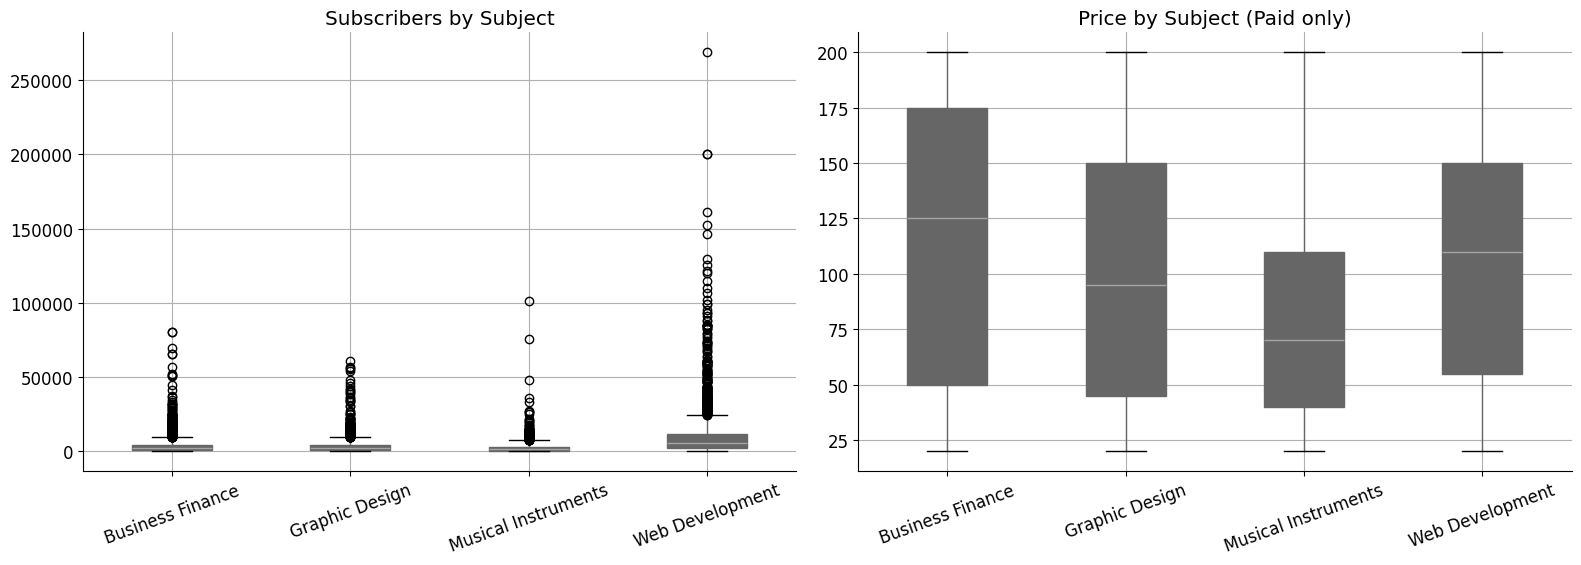

In [37]:
# Boxplot so sánh outliers theo subject
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân Phối Subscribers & Price Theo Subject (Boxplot)', fontsize=13, fontweight='bold')

df.boxplot(column='num_subscribers', by='subject', ax=axes[0],
           patch_artist=True)
axes[0].set_title('Subscribers by Subject')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

df[df['price'] > 0].boxplot(column='price', by='subject', ax=axes[1],
                              patch_artist=True)
axes[1].set_title('Price by Subject (Paid only)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Phân tích Doanh Thu & Subscribers

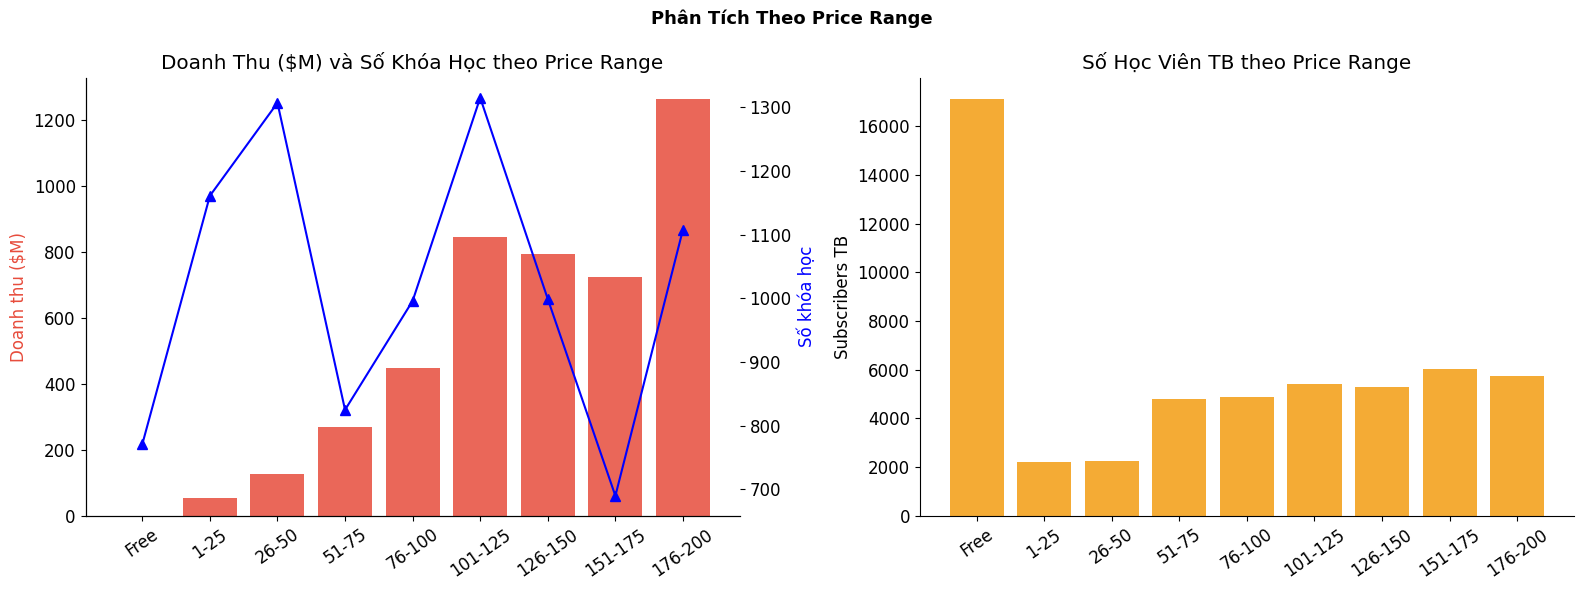

In [38]:
# Revenue & Subscribers theo price range
price_analysis = df.groupby('price_range', observed=True).agg(
    n_courses        = ('price', 'count'),
    avg_subscribers  = ('num_subscribers', 'mean'),
    total_revenue    = ('estimated_revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân Tích Theo Price Range', fontsize=13, fontweight='bold')

# Revenue
axes[0].bar(price_analysis['price_range'].astype(str),
            price_analysis['total_revenue']/1e6, color='#e74c3c', alpha=0.85)
ax2 = axes[0].twinx()
ax2.plot(price_analysis['price_range'].astype(str),
         price_analysis['n_courses'], 'b^-', markersize=7, label='Số khóa')
axes[0].set_title('Doanh Thu ($M) và Số Khóa Học theo Price Range')
axes[0].set_ylabel('Doanh thu ($M)', color='#e74c3c')
ax2.set_ylabel('Số khóa học', color='blue')
axes[0].tick_params(axis='x', rotation=35)

# Avg Subscribers
axes[1].bar(price_analysis['price_range'].astype(str),
            price_analysis['avg_subscribers'], color='#f39c12', alpha=0.85)
axes[1].set_title('Số Học Viên TB theo Price Range')
axes[1].set_ylabel('Subscribers TB')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('eda_revenue_price.png', dpi=150, bbox_inches='tight')
plt.show()

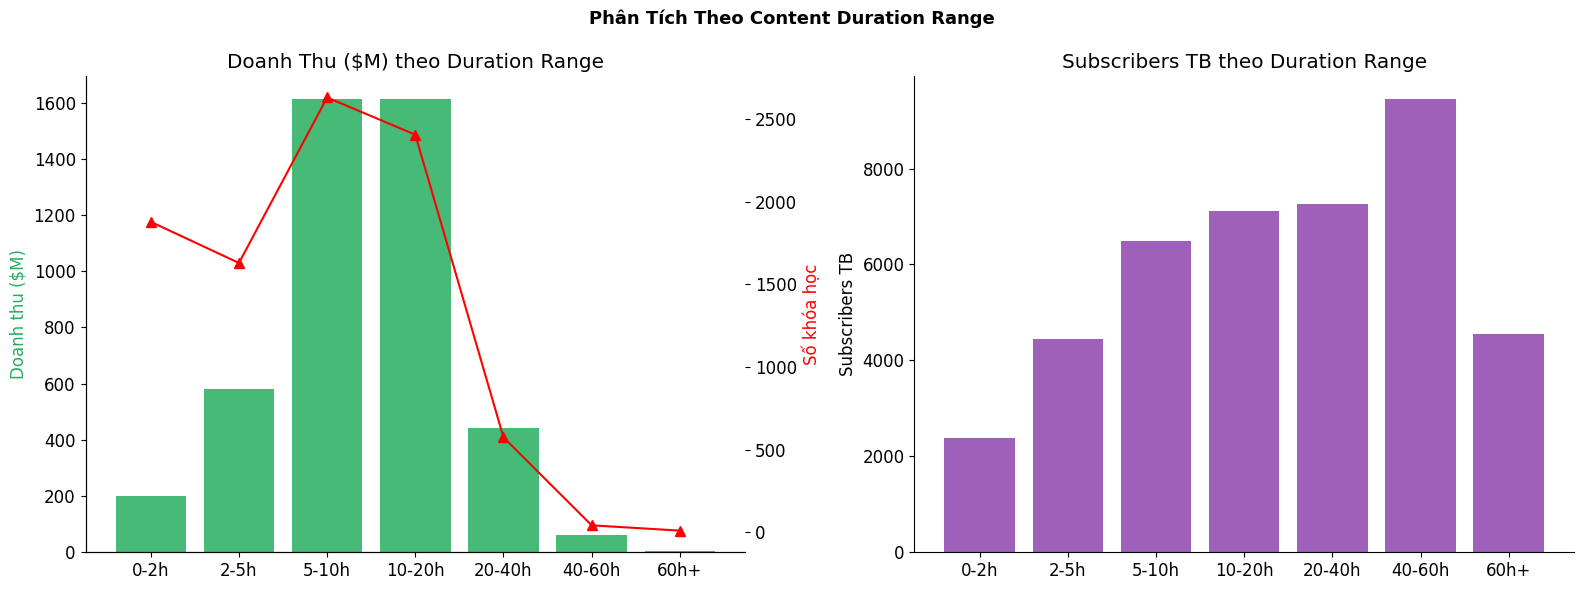

In [39]:
# Revenue & Subscribers theo duration range
dur_analysis = df.groupby('duration_range', observed=True).agg(
    n_courses        = ('price','count'),
    avg_subscribers  = ('num_subscribers','mean'),
    total_revenue    = ('estimated_revenue','sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân Tích Theo Content Duration Range', fontsize=13, fontweight='bold')

axes[0].bar(dur_analysis['duration_range'].astype(str),
            dur_analysis['total_revenue']/1e6, color='#27ae60', alpha=0.85)
ax2 = axes[0].twinx()
ax2.plot(dur_analysis['duration_range'].astype(str),
         dur_analysis['n_courses'], 'r^-', markersize=7)
axes[0].set_title('Doanh Thu ($M) theo Duration Range')
axes[0].set_ylabel('Doanh thu ($M)', color='#27ae60')
ax2.set_ylabel('Số khóa học', color='red')

axes[1].bar(dur_analysis['duration_range'].astype(str),
            dur_analysis['avg_subscribers'], color='#8e44ad', alpha=0.85)
axes[1].set_title('Subscribers TB theo Duration Range')
axes[1].set_ylabel('Subscribers TB')

plt.tight_layout()
plt.savefig('eda_revenue_duration.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Phân tích Top Khóa Học

In [40]:
if 'course_title' in df.columns:
    print('TOP 10 KHÓA HỌC NHIỀU HỌC VIÊN NHẤT')
    top_subs = df.nlargest(10, 'num_subscribers')[['course_title','subject','level',
                                                     'price','num_subscribers','num_reviews']]
    display(top_subs)

    print('\nTOP 10 KHÓA HỌC DOANH THU CAO NHẤT')
    top_rev = df.nlargest(10, 'estimated_revenue')[['course_title','subject','level',
                                                      'price','num_subscribers','estimated_revenue']]
    display(top_rev)

TOP 10 KHÓA HỌC NHIỀU HỌC VIÊN NHẤT


,course_title,subject,level,price,num_subscribers,num_reviews
2230,Learn HTML5 Programming From Scratch,Web Development,All Levels,0.00,268923,8629
5358,Node.js for Beginners: Build Real Projects,Web Development,Beginner Level,0.00,200000,10339
7219,Full Stack Kubernetes Development Course,Web Development,Beginner Level,94.99,200000,16923
776,Coding for Entrepreneurs Basic,Web Development,Beginner Level,0.00,161029,279
5672,Full Stack Python Django Development Course,Web Development,All Levels,0.00,152473,10223
4955,Modern Kubernetes Development - Complete Guide,Web Development,Beginner Level,0.00,146348,7289
5728,Master React from Zero to Hero,Web Development,All Levels,0.00,129674,13972
7519,AWS for Beginners: Build Real Projects,Web Development,All Levels,0.00,125739,12511
3385,The Web Developer Bootcamp,Web Development,All Levels,200.00,121584,27445
640,Build Your First Website in 1 Week with HTML5 ...,Web Development,Beginner Level,0.00,120291,5924



TOP 10 KHÓA HỌC DOANH THU CAO NHẤT


,course_title,subject,level,price,num_subscribers,estimated_revenue
3385,The Web Developer Bootcamp,Web Development,All Levels,200.00,121584,24316800.00
3316,The Complete Web Developer Course 2.0,Web Development,All Levels,200.00,114512,22902400.00
7219,Full Stack Kubernetes Development Course,Web Development,Beginner Level,94.99,200000,18998000.00
2829,Pianoforall - Incredible New Way To Learn Pian...,Musical Instruments,All Levels,200.00,75499,15099800.00
285,Angular 4 (formerly Angular 2) - The Complete ...,Web Development,All Levels,190.00,73783,14018770.00
2034,JavaScript: Understanding the Weird Parts,Web Development,All Levels,175.00,79612,13932100.00
7901,Professional Blockchain Finance Certification ...,Business Finance,All Levels,199.99,65593,13117944.07
8867,Full Stack Node.js Development Course,Web Development,Beginner Level,199.99,61598,12318984.02
5080,TypeScript with Redux: The Complete Course,Web Development,All Levels,174.99,66831,11694756.69
2119,Learn and Understand NodeJS,Web Development,All Levels,195.00,58208,11350560.00


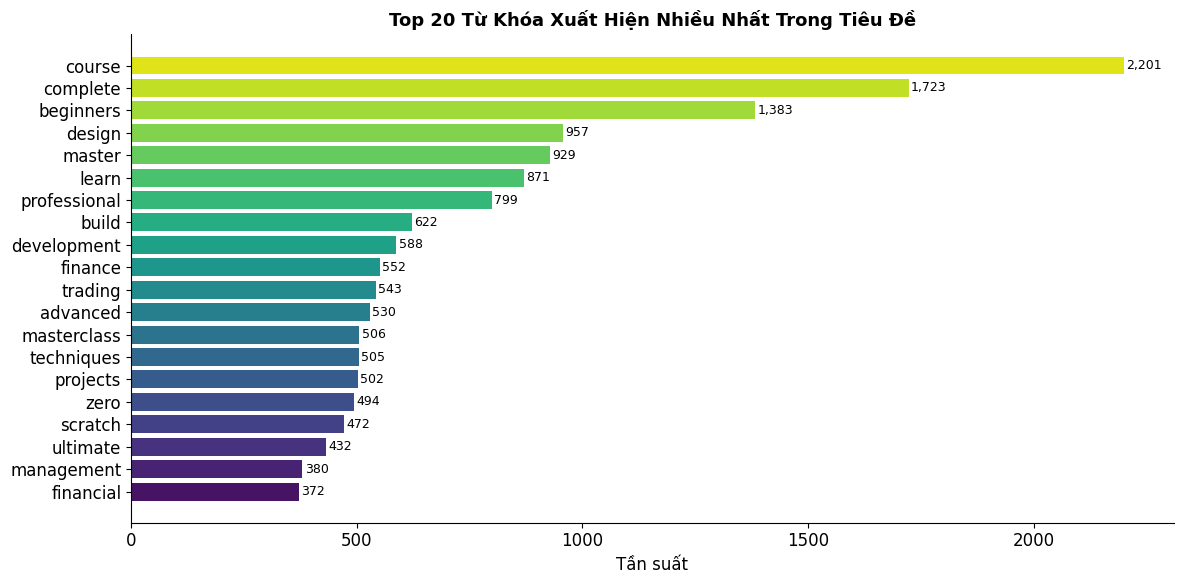

In [41]:
# Phân tích từ khóa trong tiêu đề (nếu có)
if 'course_title' in df.columns:
    from collections import Counter
    import re

    stopwords = {'the','a','an','and','or','for','to','in','of','with',
                 'on','from','how','your','you','is','are','be','by','at',
                 'this','that','it','as','was','all','has','have','do'}

    words = []
    for title in df['course_title'].dropna():
        tokens = re.findall(r'\b[a-zA-Z]{3,}\b', title.lower())
        words.extend([w for w in tokens if w not in stopwords])

    word_freq = Counter(words).most_common(20)
    words_df = pd.DataFrame(word_freq, columns=['word','count'])

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(words_df['word'][::-1], words_df['count'][::-1],
                   color=sns.color_palette('viridis', 20))
    ax.set_title('Top 20 Từ Khóa Xuất Hiện Nhiều Nhất Trong Tiêu Đề', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tần suất')
    for bar, v in zip(bars, words_df['count'][::-1]):
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('eda_keywords.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 11. Tổng kết EDA

In [42]:
print('=' * 60)
print('   TỔNG KẾT EDA - UDEMY DATASET')
print('=' * 60)
print(f'  Tổng khóa học          : {len(df):,}')
print(f'  Giai đoạn              : {df["year"].min():.0f} - {df["year"].max():.0f}')
print(f'  Tổng Subscribers       : {df["num_subscribers"].sum():,}')
print(f'  Tổng Doanh thu ước tính: ${df["estimated_revenue"].sum():,.0f}')
print(f'  Tổng thời lượng        : {df["content_duration"].sum():,.1f} giờ')
print(f'  Tỷ lệ Paid             : {df["is_paid"].mean()*100:.1f}%')
print(f'  Giá trung bình (Paid)  : ${df[df["price"]>0]["price"].mean():.2f}')
print(f'  Subscribers TB/khóa    : {df["num_subscribers"].mean():,.0f}')
print()
print('  Top Subject (doanh thu):')
top_subject = df.groupby('subject')['estimated_revenue'].sum().sort_values(ascending=False)
for s, v in top_subject.items():
    print(f'    {s:<30}: ${v/1e6:>8.1f}M')
print()
print('  Insight chính:')
print('  1. Web Development dẫn đầu mọi chỉ số')
print('  2. Năm 2020-2021: tăng trưởng mạnh do COVID-19')
print('  3. Mức giá $150-200 tối ưu về doanh thu')
print('  4. Thời lượng 5-10h thu hút nhiều học viên nhất')
print('  5. Học viên trả phí có tỷ lệ review cao hơn')
print('=' * 60)

   TỔNG KẾT EDA - UDEMY DATASET
  Tổng khóa học          : 9,172
  Giai đoạn              : 2011 - 2026
  Tổng Subscribers       : 50,502,545
  Tổng Doanh thu ước tính: $4,521,653,293
  Tổng thời lượng        : 78,628.6 giờ
  Tỷ lệ Paid             : 91.6%
  Giá trung bình (Paid)  : $103.90
  Subscribers TB/khóa    : 5,506

  Top Subject (doanh thu):
    Web Development               : $  2640.5M
    Business Finance              : $   962.6M
    Graphic Design                : $   620.4M
    Musical Instruments           : $   298.1M

  Insight chính:
  1. Web Development dẫn đầu mọi chỉ số
  2. Năm 2020-2021: tăng trưởng mạnh do COVID-19
  3. Mức giá $150-200 tối ưu về doanh thu
  4. Thời lượng 5-10h thu hút nhiều học viên nhất
  5. Học viên trả phí có tỷ lệ review cao hơn
